In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.15.0
GPU Available: []


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [3]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis', 'Untitled.ipynb']


In [4]:
dataset_path = "."

In [5]:
img_size = (224,224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 6400 images belonging to 9 classes.
Found 1600 images belonging to 9 classes.


In [6]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [7]:
for layer in base_model.layers:
    layer.trainable = False

In [8]:
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(9, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [9]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10


200/200 [==============================] - 1655s 8s/step - loss: 1.0570 - accuracy: 0.5784 - val_loss: 0.7292 - val_accuracy: 0.7113
Epoch 2/10
200/200 [==============================] - 1633s 8s/step - loss: 0.6855 - accuracy: 0.7264 - val_loss: 0.5866 - val_accuracy: 0.7700
Epoch 3/10
200/200 [==============================] - 1639s 8s/step - loss: 0.5604 - accuracy: 0.7842 - val_loss: 0.5475 - val_accuracy: 0.7900
Epoch 4/10
200/200 [==============================] - 1637s 8s/step - loss: 0.4978 - accuracy: 0.8077 - val_loss: 0.4908 - val_accuracy: 0.8081
Epoch 5/10
200/200 [==============================] - 1652s 8s/step - loss: 0.4351 - accuracy: 0.8323 - val_loss: 0.4869 - val_accuracy: 0.8062
Epoch 6/10
200/200 [==============================] - 1652s 8s/step - loss: 0.4033 - accuracy: 0.8391 - val_loss: 0.4458 - val_accuracy: 0.8269
Epoch 7/10
200/200 [==============================] - 1635s 8s/step - loss: 0.3713 - accuracy: 0.8559 - val_loss: 0.4831 - val_accurac

In [11]:
model.save("kvasir_vgg16_model.h5")

C:\Users\ajayk\.conda\envs\kvasir_env\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


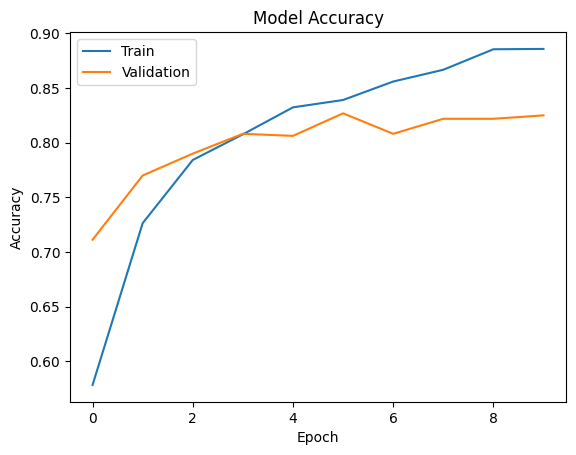

In [12]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

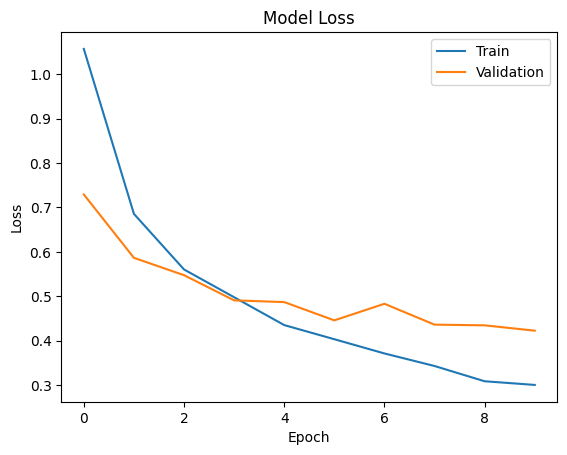

In [13]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [14]:
import os
print(os.listdir("polyps")[:10])

['polyps']


In [15]:
print(os.listdir("polyps/polyps")[:10])

['00072d5f-7cd8-434c-8a5a-1a0bb2c9711d.jpg', '0014d89e-5afa-4186-99f9-4400c8c58a18.jpg', '001696c2-c627-4193-ad14-dda8945ad13f.jpg', '006338df-e61e-4725-bb6c-dd0620f11cdc.jpg', '007e4d46-c617-418f-8a04-d34716adcb65.jpg', '00a98927-bbfc-405a-9060-b5e7ccf6b811.jpg', '00e301cd-5438-4ed7-846b-7d8eaa7cf4b8.jpg', '00ffa659-7474-47fb-aeb1-3ef1ac88f6b3.jpg', '01a72489-11c2-4891-a2b8-7a0fb1181b7c.jpg', '01c32c31-d74e-4cec-a0a1-0c2f51451af0.jpg']


In [16]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "polyps/polyps/00072d5f-7cd8-434c-8a5a-1a0bb2c9711d.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print(prediction)

1/1 [==============================] - 1s 739ms/step
[[1.0770976e-04 5.0846291e-01 1.6318448e-03 7.5410132e-04 3.8670603e-04
  1.7868418e-01 1.8111146e-03 3.0475873e-01 3.4027370e-03]]


In [17]:
class_names = list(train_data.class_indices.keys())

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = np.max(prediction)

print("Prediction:", predicted_class)
print("Confidence:", confidence*100, "%")

Prediction: dyed-lifted-polyps
Confidence: 50.846290588378906 %


(-0.5, 223.5, 223.5, -0.5)

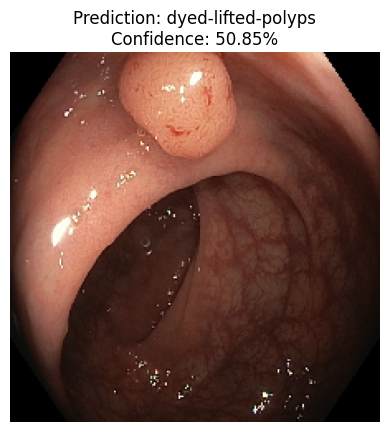

In [18]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence*100:.2f}%")
plt.axis("off")

In [19]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "polyps/polyps/01c32c31-d74e-4cec-a0a1-0c2f51451af0.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print(prediction)

1/1 [==============================] - 0s 311ms/step
[[9.3451054e-06 1.2129919e-03 2.3537601e-04 3.2798009e-05 7.7441842e-03
  4.7459148e-04 2.8580954e-04 8.2797748e-01 1.6202742e-01]]


In [20]:
class_names = list(train_data.class_indices.keys())

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = np.max(prediction)

print("Prediction:", predicted_class)
print("Confidence:", confidence*100, "%")

Prediction: polyps
Confidence: 82.79774785041809 %


(-0.5, 223.5, 223.5, -0.5)

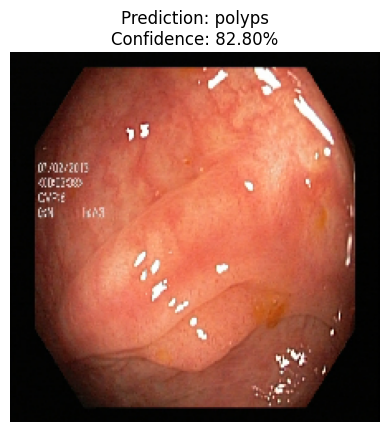

In [21]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence*100:.2f}%")
plt.axis("off")

In [22]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "polyps/polyps/00a98927-bbfc-405a-9060-b5e7ccf6b811.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print(prediction)

1/1 [==============================] - 0s 310ms/step
[[2.2079787e-06 8.3248573e-04 1.4360755e-04 9.8095561e-06 2.1834886e-03
  1.3440962e-05 4.0440176e-05 1.3832834e-01 8.5844618e-01]]


In [23]:
class_names = list(train_data.class_indices.keys())

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = np.max(prediction)

print("Prediction:", predicted_class)
print("Confidence:", confidence*100, "%")

Prediction: ulcerative-colitis
Confidence: 85.84461808204651 %


(-0.5, 223.5, 223.5, -0.5)

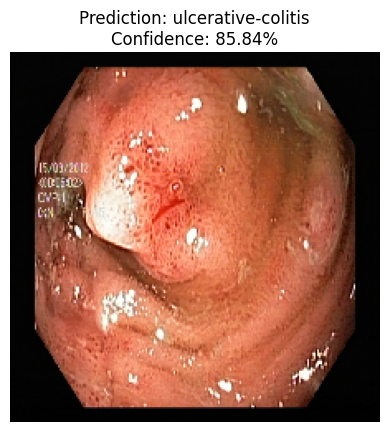

In [24]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence*100:.2f}%")
plt.axis("off")

In [14]:
import os

print(os.listdir("normal-z-line/normal-z-line")[:10])

['00bee375-36d2-4ba9-89e5-bd6132d79c0c.jpg', '00db2b25-bb71-4218-a076-9d2449a23f2e.jpg', '016858b4-36f8-47d7-97ca-1570bcaba413.jpg', '01a146ce-c9a3-42af-9f53-573e90975abe.jpg', '01c1453c-dcad-4e16-a0d5-645e833ce82c.jpg', '01cf965e-28f2-4fc2-9d42-dace76989ca2.jpg', '026f0d8f-2272-4e50-b73e-742b580619d7.jpg', '02896af8-ebb2-4ed0-94dd-6a76fbf7f00b.jpg', '032d6b45-f706-444d-b4d9-c11a4df4d364.jpg', '03be9506-bf4a-42e5-b18b-ec8388860fae.jpg']


In [15]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "normal-z-line/normal-z-line/032d6b45-f706-444d-b4d9-c11a4df4d364.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print(prediction)

1/1 [==============================] - 1s 717ms/step
[[0.01249647 0.16541022 0.15508729 0.15101129 0.09683713 0.05072014
  0.20696141 0.0731299  0.08834619]]


In [16]:
class_names = list(train_data.class_indices.keys())

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = np.max(prediction)

print("Prediction:", predicted_class)
print("Confidence:", confidence*100, "%")

Prediction: normal-z-line
Confidence: 20.696140825748444 %


(-0.5, 223.5, 223.5, -0.5)

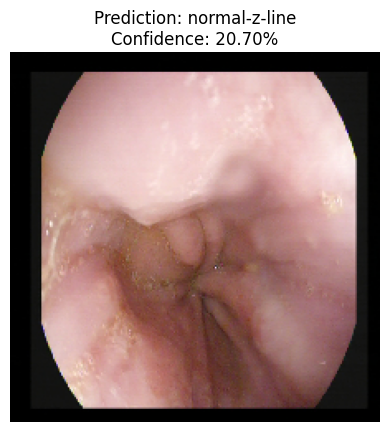

In [17]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence*100:.2f}%")
plt.axis("off")

In [18]:
import os

print(os.listdir("dyed-resection-margins/dyed-resection-margins")[:10])

['003808ff-c349-481a-9c91-e9acf1c181b7.jpg', '0062bbf3-58d7-435d-b0ca-381703c39911.jpg', '009bd044-4a5a-4c81-b481-d20fb223cd81.jpg', '00adb051-3e76-4482-b0e5-5207a028470b.jpg', '01086b46-817d-4f20-8aba-4a7b9347ab1c.jpg', '016cc0c1-2a9e-464c-884f-0997561f7dde.jpg', '01cbcacb-6d33-41ba-9aa7-e37907f9281b.jpg', '026c7b7a-f09e-424a-a27f-3b6081ed8187.jpg', '02d224ad-8c65-4b2d-aa9d-ea8aed60d37d.jpg', '02f7c707-17a1-4e37-a2af-6a202273e656.jpg']


In [21]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "dyed-resection-margins/dyed-resection-margins/016cc0c1-2a9e-464c-884f-0997561f7dde.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print(prediction)

1/1 [==============================] - 0s 301ms/step
[[0.01030688 0.35711133 0.06153801 0.10451257 0.07558078 0.03205637
  0.15706694 0.06575835 0.13606876]]


In [22]:
class_names = list(train_data.class_indices.keys())

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = np.max(prediction)

print("Prediction:", predicted_class)
print("Confidence:", confidence*100, "%")

Prediction: dyed-lifted-polyps
Confidence: 35.71113348007202 %


(-0.5, 223.5, 223.5, -0.5)

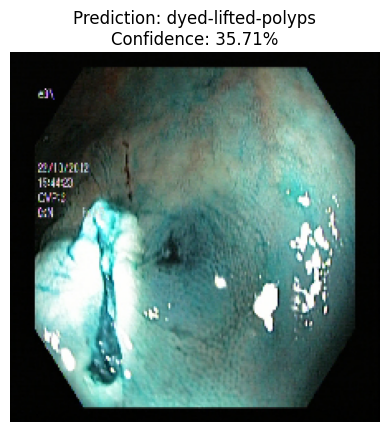

In [23]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence*100:.2f}%")
plt.axis("off")